In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

  Using cached qiskit-1.2.4-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached symengine-0.13.0.tar.gz (114 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached qiskit-1.2.4-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.8 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for symengine (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [30 lines of output]
      /tmp/pip-build-env-34mwjbv3/overlay/lib/python3.14/site-packages/setuptools/_vendor/wheel/bdist_wheel.py:4: FutureWarning: The 'wheel' package is no longer the canonical location of th

In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

In [ ]:
backend = BasicSimulator()

def measure_bit(circuit):
    compiled = transpile(circuit, backend)
    job = backend.run(compiled, shots=1)
    result = job.result()
    counts = result.get_counts(compiled)
    return int(list(counts.keys())[0])

def random_bits(n):
    bits = []
    for i in range(n):
        qc = QuantumCircuit(1, 1)
        qc.h(0)
        qc.measure(0, 0)
        bits = bits + [measure_bit(qc)]
    return bits

def prepare_bb84_qubit(bit, basis):
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)
    if basis == 1:
        qc.h(0)
    return qc

def measure_bb84_qubit(bit, send_basis, receive_basis):
    qc = prepare_bb84_qubit(bit, send_basis)
    if receive_basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    return measure_bit(qc)

def basis_name(basis):
    if basis == 0:
        return "Z"
    else:
        return "X"

def bits_to_string(bits):
    return "".join([str(bit) for bit in bits])

def print_attacker_report(n, threshold, alice_bits, alice_bases, eve_bases, eve_results, bob_bases, bob_results, matching_positions, alice_key, bob_key, errors, error_rate, attack_detected):
    print("BB84 with intercept-resend attacker")
    print("----------------------------------")
    print("Basis names: Z = computational, X = diagonal")
    print("Number of qubits sent:", n)
    print("Matching bases:", len(matching_positions))
    print("Sifted key length:", len(alice_key))
    print("Alice sifted key:", bits_to_string(alice_key))
    print("Bob sifted key:  ", bits_to_string(bob_key))
    print("Errors in sifted key:", errors)
    print(f"Error rate: {100 * error_rate:.2f}%")
    print(f"Detection threshold: {100 * threshold:.2f}%")
    print("Attack detected:", attack_detected)
    print()
    print("Kept positions only")
    print()
    print("Position | A bit | A basis | E basis | E result | B basis | B result | Match")
    print("-------------------------------------------------------------------------------")
    for i in matching_positions:
        match = "Yes" if alice_bits[i] == bob_results[i] else "No"
        print(f"{i:>8} | {alice_bits[i]:>5} | {basis_name(alice_bases[i]):>7} | {basis_name(eve_bases[i]):>7} | {eve_results[i]:>8} | {basis_name(bob_bases[i]):>7} | {bob_results[i]:>8} | {match}")

BB84 with intercept-resend attacker
----------------------------------
Basis names: Z = computational, X = diagonal
Number of qubits sent: 100
Matching bases: 40
Sifted key length: 40
Alice sifted key: 0100010100100011011111011000100001010110
Bob sifted key:   0101000000100111010111011110000101010111
Errors in sifted key: 10
Error rate: 25.00%
Detection threshold: 12.00%
Attack detected: True

Kept positions only

Position | A bit | A basis | E basis | E result | B basis | B result | Match
-------------------------------------------------------------------------------
       1 |     0 |       Z |       Z |        0 |       Z |        0 | Yes
       3 |     1 |       X |       X |        1 |       X |        1 | Yes
       6 |     0 |       Z |       X |        1 |       Z |        0 | Yes
       8 |     0 |       X |       Z |        1 |       X |        1 | No
      10 |     0 |       X |       Z |        1 |       X |        0 | Yes
      11 |     1 |       X |       Z |        1 |  

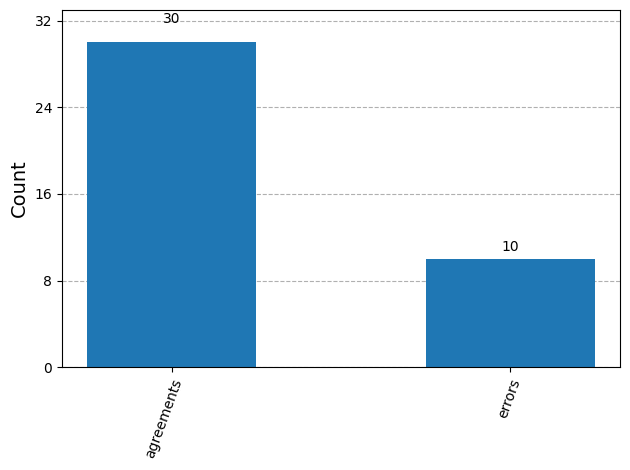

In [4]:
# BB84 with a simple intercept-resend attacker

n = 100
threshold = 0.12

# Alice chooses random bits and random bases.
alice_bits = random_bits(n)
alice_bases = random_bits(n)

# Eve intercepts every qubit, measures it in a random basis, and resends.
eve_bases = random_bits(n)
eve_results = []
for i in range(n):
    eve_results = eve_results + [measure_bb84_qubit(alice_bits[i], alice_bases[i], eve_bases[i])]

# Bob measures the resent qubits in his own random bases.
bob_bases = random_bits(n)
bob_results = []
for i in range(n):
    bob_results = bob_results + [measure_bb84_qubit(eve_results[i], eve_bases[i], bob_bases[i])]

# Alice and Bob compare bases and keep only matching positions.
matching_positions = []
for i in range(n):
    if alice_bases[i] == bob_bases[i]:
        matching_positions = matching_positions + [i]

alice_key = [alice_bits[i] for i in matching_positions]
bob_key = [bob_results[i] for i in matching_positions]

errors = 0
for i in range(len(alice_key)):
    if alice_key[i] != bob_key[i]:
        errors = errors + 1

if len(alice_key) > 0:
    error_rate = errors / len(alice_key)
else:
    error_rate = 0

attack_detected = error_rate > threshold

print_attacker_report(n, threshold, alice_bits, alice_bases, eve_bases, eve_results, bob_bases, bob_results, matching_positions, alice_key, bob_key, errors, error_rate, attack_detected)

plot_histogram({"agreements": len(alice_key) - errors, "errors": errors})